# Task 2
Requesting data from the Baltic Transparency-Dashboard API, ploting graphs from the retrieved data and assessing regulation activities.

In [45]:
import io
import json
import zipfile

import pandas as pd
import requests

### Task 2.1.
Requesting data from the Baltic Transparency-Dashboard API.

**What this section does:** Downloads the two datasets, saves local JSON copies, and turns the API responses into tables that are easier to analyse.

In [46]:
# API endpoint and filters for the two datasets and the selected day.
api_url = "https://api-baltic.transparency-dashboard.eu/api/v1/export-multiple"
request_parameters = {
    "id": "activations_afrr,imbalance_volumes_v2",
    "start_date": "2025-09-22T00:00",
    "end_date": "2025-09-22T23:59",
    "output_time_zone": "EET",
    "output_format": "json",
    "json_header_groups": 0,
}
target_local_date = pd.Timestamp("2025-09-22").date()
local_timezone = "Europe/Tallinn"

exports = {}
try:
    # Request the ZIP archive containing one JSON file per dataset.
    response = requests.get(
        api_url,
        params=request_parameters,
        headers={"accept": "application/zip"},
        timeout=30,
    )
    response.raise_for_status()

    # Save each downloaded JSON dataset and keep it available in memory.
    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        for filename in archive.namelist():
            dataset = json.loads(archive.read(filename))
            exports[dataset["id"]] = dataset
            with open(f"{dataset['id']}.json", "w", encoding="utf-8") as json_file:
                json.dump(dataset, json_file, indent=2)
    print("Data retrieved from the live API.")
except requests.exceptions.RequestException as error:
    # Use saved JSON files if the live API cannot be reached.
    print(f"API request failed ({error}); falling back to local export files.")
    for dataset_id in ["activations_afrr", "imbalance_volumes_v2"]:
        with open(f"{dataset_id}.json", "r", encoding="utf-8") as json_file:
            exports[dataset_id] = json.load(json_file)


def export_to_dataframe(dataset):
    # Build readable column names from the API metadata.
    column_names = []
    for column in dataset["columns"]:
        group = column.get("group_level_0")
        label = column.get("label")
        column_names.append(": ".join(str(part) for part in [group, label] if part))

    rows = []
    for interval in dataset["timeseries"]:
        # Convert API timestamps to local time and remove timezone labels for display.
        interval_start = pd.Timestamp(interval["from"]).tz_convert(local_timezone).tz_localize(None)
        interval_end = pd.Timestamp(interval["to"]).tz_convert(local_timezone).tz_localize(None)
        row = {"from": interval_start, "to": interval_end}
        row.update(dict(zip(column_names, interval["values"])))
        rows.append(row)

    # Return a time-indexed table containing only the requested local date.
    dataframe = pd.DataFrame(rows).set_index("from").sort_index()
    return dataframe[dataframe.index.date == target_local_date]


# Convert both API datasets into pandas tables used by the later metrics.
activations_df = export_to_dataframe(exports["activations_afrr"])
imbalance_df = export_to_dataframe(exports["imbalance_volumes_v2"])

print(f"Retrieved {len(activations_df)} local intervals for {target_local_date}")
print(f"Local interval range: {activations_df.index.min()} to {activations_df['to'].max()}")
display(activations_df.head())
display(imbalance_df.head())

Data retrieved from the live API.
Retrieved 96 local intervals for 2025-09-22
Local interval range: 2025-09-22 00:00:00 to 2025-09-23 00:00:00


,to,Estonia: Upward,Estonia: Downward,Latvia: Upward,Latvia: Downward,Lithuania: Upward,Lithuania: Downward
from,,,,,,,
2025-09-22 00:00:00,2025-09-22 00:15:00,0.002,1.570,0.009,0.891,0.00,6.30
2025-09-22 00:15:00,2025-09-22 00:30:00,0.027,0.641,0.540,0.089,0.25,0.72
2025-09-22 00:30:00,2025-09-22 00:45:00,0.130,0.760,1.257,0.146,0.10,0.78
2025-09-22 00:45:00,2025-09-22 01:00:00,0.022,0.689,0.017,0.955,0.00,12.98
2025-09-22 01:00:00,2025-09-22 01:15:00,1.014,0.344,3.260,0.377,0.00,1.55


,to,Estonia,Latvia,Lithuania
from,,,,
2025-09-22 00:00:00,2025-09-22 00:15:00,10.711,-2.746,5.011
2025-09-22 00:15:00,2025-09-22 00:30:00,13.394,-0.702,-0.038
2025-09-22 00:30:00,2025-09-22 00:45:00,15.316,1.999,-9.780
2025-09-22 00:45:00,2025-09-22 01:00:00,14.849,6.053,2.289
2025-09-22 01:00:00,2025-09-22 01:15:00,15.610,-0.608,3.688


In [47]:
imbalance_df.tail(5)

,to,Estonia,Latvia,Lithuania
from,,,,
2025-09-22 22:45:00,2025-09-22 23:00:00,16.679,6.470,24.055
2025-09-22 23:00:00,2025-09-22 23:15:00,10.326,-5.166,-3.967
2025-09-22 23:15:00,2025-09-22 23:30:00,15.779,0.347,-6.481
2025-09-22 23:30:00,2025-09-22 23:45:00,18.826,8.347,-3.948
2025-09-22 23:45:00,2025-09-23 00:00:00,22.313,9.881,14.156


### Task 2.2.
Plotting aFRR activation and imbalance volume graphs from the retrieved data.

**What this section does:** Sets the country colours and draws the activation and imbalance data over time so the daily patterns can be compared visually.

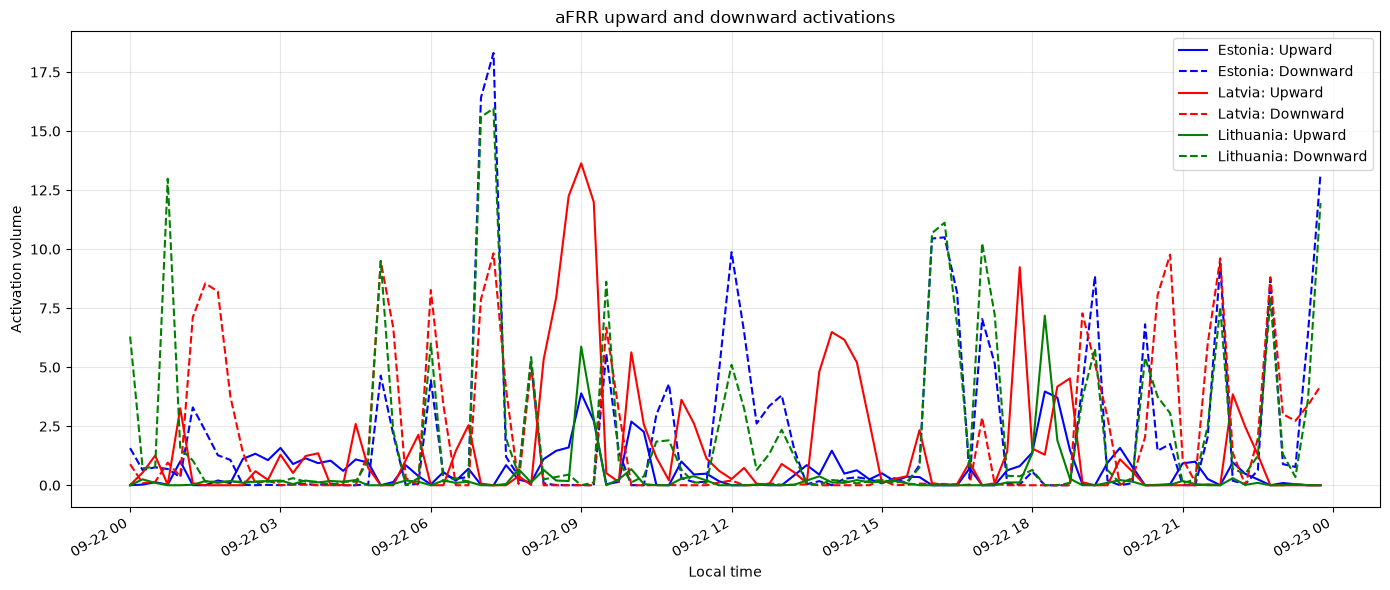

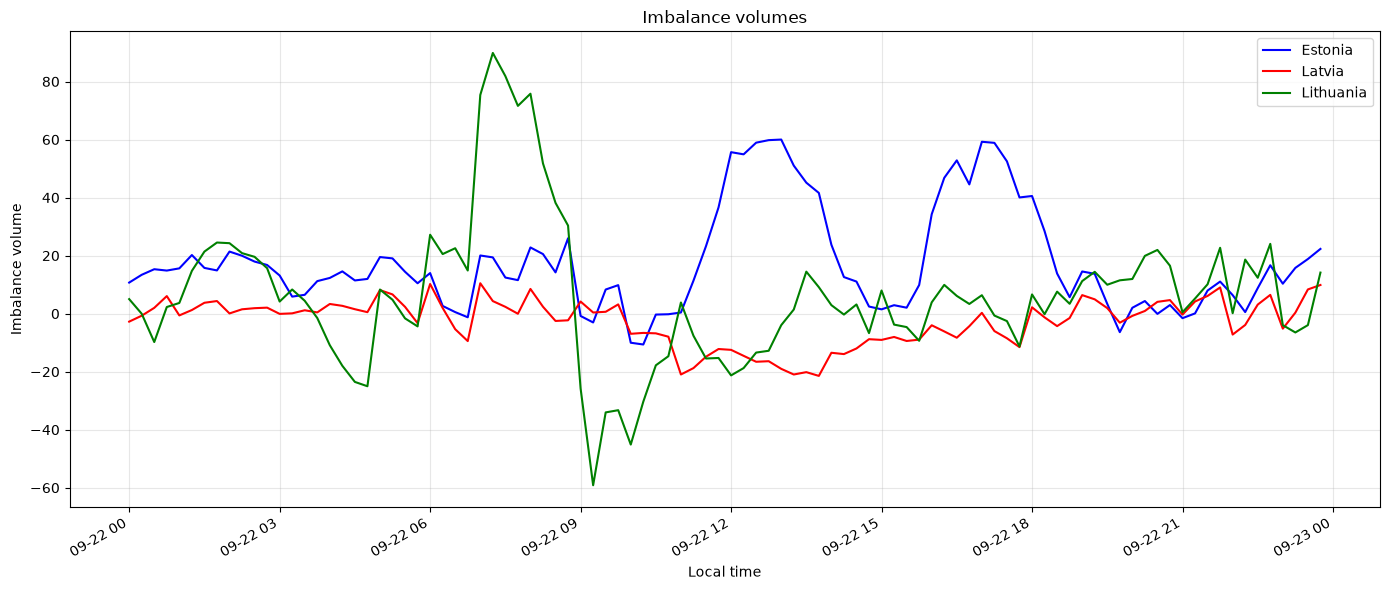

In [48]:
import matplotlib.pyplot as plt

# Use consistent colours for the three countries in every chart.
country_colors = {
    "Latvia": "red",
    "Estonia": "blue",
    "Lithuania": "green",
}


def country_color(series_name):
    # Find the country name inside a dataframe column name.
    for country, color in country_colors.items():
        if country.lower() in series_name.lower():
            return color
    return "black"


def activation_line_style(series_name):
    # Show upward activation with a solid line and downward with a dashed line.
    name = series_name.lower()
    if "downward" in name or "down" in name:
        return "--"
    return "-"


def plot_series(dataframe, title, ylabel, line_style=None):
    # Plot every data column except the interval-end helper column.
    value_columns = dataframe.drop(columns=["to"], errors="ignore").columns
    figure, axis = plt.subplots(figsize=(14, 6))
    for column in value_columns:
        style = line_style(column) if line_style else "-"
        axis.plot(
            dataframe.index,
            dataframe[column],
            color=country_color(column),
            linestyle=style,
            label=column,
        )
    axis.set_title(title)
    axis.set_xlabel("Local time")
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)
    axis.legend()
    figure.autofmt_xdate()
    plt.tight_layout()
    plt.show()


# Draw the activation chart and the imbalance chart for the selected day.
plot_series(
    activations_df,
    "aFRR upward and downward activations",
    "Activation volume",
    activation_line_style,
)
plot_series(imbalance_df, "Imbalance volumes", "Imbalance volume")

The aFRR activation graph shows the total upward and downward aFRR activations in all three Baltic countries. The graph is quite messy so we will need additional metrics to better understand the regulation activities done on this day. However, it can be seen that Latvia had the highest peaks of upward aFRR activations, while Estonia had the highest peaks of downward aFRR activations.

From the imbalance volume graph, it can be observed that each individual country in the Baltic region has a very different imbalance pattern. Lithuania has the highest peaks of both surplus and deficit imbalances, while Estonia has a more consistent surplus imbalance pattern. Latvia, on the other hand, has a more balanced pattern with smaller peaks in both surplus and deficit imbalances. On this day Lithuania had very high imbalance fluctuations, rapidly changing from a large surplus to a large deficit imbalance.

 As can be expected, the peak of downward aFRR activation corresponds with the highest peak of surplus imbalance (at 8:00), and the upward aFRR activation peak corresponds with the highest peak of deficit imbalance (at 9:00). However, in both cases the aFRR activation peaks were not in the same country as the imbalance peaks, which indicates that the aFRR activations were not only used to regulate the imbalances in the same country, but also to regulate imbalances in other countries. This is consistent with the fact that the Baltic countries are a part of one interconnected Load-Frequency Control (LFC) area and can support each other in case of imbalances.

### Calculating additional metrics and assessing regulation activities based on the retrieved data.

#### **Metric Nr.1:** Per-interval imbalance coverage ratio

**What this section does:** Compares activated aFRR volume with the absolute imbalance in each 15-minute interval. It reports typical coverage ratios for each country and the Baltic region.

In [49]:
# Use 0.25 hours because every record represents a 15-minute interval.
interval_hours = 15 / 60
countries = list(country_colors)
coverage_rows = []

# Ignore very small imbalances when calculating the materiality-filtered ratio.
materiality_threshold_mwh = 5.0  # ignore intervals with a near-zero imbalance

for country in countries:
    # Read upward and downward aFRR, then add them to get total activated volume.
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    activated_volume = upward + downward
    absolute_imbalance = imbalance.abs()

    # Calculate aFRR activation divided by the absolute imbalance for each interval.
    nonzero_imbalance = absolute_imbalance > 0
    coverage_ratio = activated_volume[nonzero_imbalance] / absolute_imbalance[nonzero_imbalance]

    # Repeat the calculation only for intervals with a material imbalance.
    material_imbalance = absolute_imbalance > materiality_threshold_mwh
    material_ratio = activated_volume[material_imbalance] / absolute_imbalance[material_imbalance]

    coverage_rows.append(
        {
            "Country": country,
            "Mean coverage ratio (all intervals)": coverage_ratio.mean(),
            "Median coverage ratio (all intervals)": coverage_ratio.median(),
            f"Mean coverage ratio (|imbalance| > {materiality_threshold_mwh} MWh)": material_ratio.mean(),
        }
    )

# Add the same interval-level calculations for the Baltic region as a whole.
regional_upward = sum(
    activations_df[f"{country}: Upward"].astype(float) for country in countries
)
regional_downward = sum(
    activations_df[f"{country}: Downward"].astype(float) for country in countries
)
regional_imbalance = sum(
    imbalance_df[country].astype(float).reindex(activations_df.index)
    for country in countries
)
regional_activated_volume = regional_upward + regional_downward
regional_absolute_imbalance = regional_imbalance.abs()
regional_nonzero_imbalance = regional_absolute_imbalance > 0
regional_coverage_ratio = (
    regional_activated_volume[regional_nonzero_imbalance]
    / regional_absolute_imbalance[regional_nonzero_imbalance]
)
regional_material_imbalance = regional_absolute_imbalance > materiality_threshold_mwh
regional_material_ratio = (
    regional_activated_volume[regional_material_imbalance]
    / regional_absolute_imbalance[regional_material_imbalance]
)
coverage_rows.append(
    {
        "Country": "Baltic region (net)",
        "Mean coverage ratio (all intervals)": regional_coverage_ratio.mean(),
        "Median coverage ratio (all intervals)": regional_coverage_ratio.median(),
        f"Mean coverage ratio (|imbalance| > {materiality_threshold_mwh} MWh)": regional_material_ratio.mean(),
    }
)

coverage_df = pd.DataFrame(coverage_rows).set_index("Country")
print(
    "Note: the mean and median differ sharply because the ratio explodes whenever "
    "the imbalance denominator is small in a given interval. Prefer the "
    "materiality-filtered mean, or the aggregate (sum/sum) coverage further below, "
    "over the unfiltered mean."
)
display(coverage_df.round(3))

Note: the mean and median differ sharply because the ratio explodes whenever the imbalance denominator is small in a given interval. Prefer the materiality-filtered mean, or the aggregate (sum/sum) coverage further below, over the unfiltered mean.


,Mean coverage ratio (all intervals),Median coverage ratio (all intervals),Mean coverage ratio (|imbalance| > 5.0 MWh)
Country,,,
Latvia,2.432,0.718,0.379
Estonia,0.948,0.150,0.176
Lithuania,1.134,0.104,0.195
Baltic region (net),0.641,0.310,0.338


In simple terms here we calculate in each time step how much imbalance is covered by aFRR activations using the formula: 

##### **Per-interval imbalance coverage ratio = (aFRR activations at time t) / ∣imbalance at time t∣**

Then we sumarize those ratios using mean, median and a filtered mean (removing near-zero imnalance values). The results are presented in the table above. This shows the typical relationship across individual 15-minute intervals and reveals variability. However, the mean can be distorted when the imbalance is close to zero. Therefore, the median and filtered mean are also reported to provide a more robust summary of the typical coverage ratio.

The higher the coverage ratio is, the larger share of imbalance is covered by aFRR activations. The findings make intuitive sense, as on this day Latvia had the smallest share of imbalance and thus could cover a larger share of it with aFRR activations. On the other hand, Lithuania had the largest share of imbalance and thus could cover a smaller share of it with aFRR activations.

Overall, on this day aproximately 31% of the Baltic region's total imbalance was accounted for by aFRR activations. The rest of the imbalance was covered by mFRR activations and cross-border exchanges, which are not included in this analysis. The findings suggest that aFRR activations play a significant role in balancing the Baltic region's electricity system, but there is still room for improvement in terms of covering the total imbalance.

##### **Metric Nr.2:** Energy-weighted aggregate imbalance coverage ratio 

**What this section does:** Converts the 15-minute MW values into MWh, adds the daily totals, and compares total aFRR activation energy with gross regional imbalance energy.

In [50]:
energy_rows = []

for country in countries:
    # Convert each country's 15-minute activation and imbalance values into daily energy.
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    activated_volume = upward + downward
    absolute_imbalance = imbalance.abs()
    energy_rows.append(
        {
            "Country": country,
            "aFRR activated (MWh)": activated_volume.sum() * interval_hours,
            "Absolute imbalance (MWh)": absolute_imbalance.sum() * interval_hours,
            "Aggregate coverage (%)": (
                activated_volume.sum() / absolute_imbalance.sum() * 100
                if absolute_imbalance.sum() else float("nan")
            ),
        }
    )

# Gross regional imbalance sums each country's absolute imbalance, avoiding cancellation.
regional_gross_absolute_imbalance = sum(
    imbalance_df[country].astype(float).reindex(activations_df.index).abs()
    for country in countries
)
energy_rows.append(
    {
        "Country": "Baltic region (gross)",
        "aFRR activated (MWh)": regional_activated_volume.sum() * interval_hours,
        "Absolute imbalance (MWh)": regional_gross_absolute_imbalance.sum() * interval_hours,
        "Aggregate coverage (%)": (
            regional_activated_volume.sum()
            / regional_gross_absolute_imbalance.sum()
            * 100
            if regional_gross_absolute_imbalance.sum() else float("nan")
        ),
    }
)

# Compare gross and net regional imbalance to show how much cross-country cancellation occurs. 
# Only used to illustrate the effect of netting, not a real metric.
energy_rows.append(
    {
        "Country": "Baltic region (net, for reference only)",
        "aFRR activated (MWh)": regional_activated_volume.sum() * interval_hours,
        "Absolute imbalance (MWh)": regional_absolute_imbalance.sum() * interval_hours,
        "Aggregate coverage (%)": (
            regional_activated_volume.sum()
            / regional_absolute_imbalance.sum()
            * 100
            if regional_absolute_imbalance.sum() else float("nan")
        ),
    }
)

energy_df = pd.DataFrame(energy_rows).set_index("Country")
netting_effect_mwh = (
    regional_gross_absolute_imbalance.sum() - regional_absolute_imbalance.sum()
) * interval_hours

display(energy_df.round(3))

,aFRR activated (MWh),Absolute imbalance (MWh),Aggregate coverage (%)
Country,,,
Latvia,83.589,148.741,56.198
Estonia,71.352,441.517,16.161
Lithuania,64.322,403.701,15.933
Baltic region (gross),219.263,993.958,22.060
"Baltic region (net, for reference only)",219.263,704.122,31.140


Here we convert the imbalance and aFRR activations from MW to MWh by multiplying the values by 0.25, as the data is provided in 15-minute intervals. The resulting values are then summed up to obtain the total imbalance and aFRR activations for each country.

The aggregate coverage ratio describes the share of gross imbalance that is covered by aFRR activations.For calculating the aggregate coverage ratio, we use the following formula:

##### **energy-weighted daily ratio = ∑ ∣imbalance energy∣ / ∑ (aFRR activation energy)**

For the calculation of the aggregate coverage ratio, we use the **gross imbalance** energy, which is the sum of the absolute values of the imbalance energy for each country ( Gross imbalance(t) = ∣Latvia(t)∣ + ∣Estonia(t)∣ + ∣Lithuania(t)∣ ), then summed across each time step so it reflects the true total local imbalance being managed. 



This give a summary of the total share of imbalance energy that is covered by aFRR activations across the entire day. The energy-weighted daily ratio is a more robust measure than the per-interval coverage ratio, as it takes into account the total energy involved in the imbalances and activations, rather than just the average of individual intervals.

From this data we can see that on this day Estonia had the highest absolute imbalance with 440 MWh, followed closely by Lithuania with 404 MWh and to a lesser extent by Latvia with 149 MWh. However, when we look at the aFRR activations, we see that Latvia had the highest absolute aFRR activation (84 MWh), followed by Estonia (71 MWh) and Lithuania (64 MWh). In terms of covering imbalance in the Baltic region, 22% of the gross imbalance energy was covered by aFRR activations.

​
Side note: 

As mentioned above, we use **gross imbalance** to ensure that all imbalances are accounted for, regardless of their location within the region. On the other hand, using **net imbalance** would let a surplus in one country cancel a deficit in another before taking the absolute value, understating that total by a wide margin. Since aFRR activation is always positive and never cancels across countries, and factually there can be a defficit in one country while there is a surplus in another, gross is the correct figure to compare against total activated volume.

#### **Metric Nr.3:** Correlation between aFRR activations and imbalance direction and magnitude

**What this section does:** Checks whether stronger surpluses or deficits tend to come with stronger corrective aFRR activation in the same time interval.

In [51]:
correlation_rows = []

for country in countries:
    # Give upward activation a negative sign and downward activation a positive sign.
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    signed_activation = downward - upward
    correlation_rows.append(
        {
            "Country": country,
            # Pearson correlation checks whether direction and magnitude move together.
            "Pearson correlation": signed_activation.corr(imbalance),
        }
    )

# Repeat the correlation after aggregating all three countries into one Baltic series.
regional_signed_activation = regional_downward - regional_upward
correlation_rows.append(
    {
        "Country": "Baltic region (net)",
        "Pearson correlation": regional_signed_activation.corr(regional_imbalance),
    }
)

correlation_df = pd.DataFrame(correlation_rows).set_index("Country")
display(correlation_df.round(3))

,Pearson correlation
Country,
Latvia,0.499
Estonia,0.346
Lithuania,0.337
Baltic region (net),0.530


Here we check if the net local aFRR activation directions (upward and downward) correlate with the imbalance directions (surplus and deficit) and magnitudes in that region using the Pearson correlation coefficient. We also compare the overall Baltic region's imbalance direction and magnitude with the net aFRR activation direction and magnitude. In simple terms we check if downward aFRR activations are used to counteract surplus imbalance and upward aFRR activations are used to counteract deficit imbalance. The Pearson correlation coefficient ranges from -1 to 1, where -1 indicates a perfect negative correlation, 0 indicates no correlation, and 1 indicates a perfect positive correlation.

We see that there is a clear, yet not very strong correlation between the imbalance direction and the net aFRR activation direction in each of the Baltic countries. The correlation is strongest in Latvia, where the Pearson correlation coefficient is aproximatley 0.5, indicating a moderate positive correlation. In Lithuania and Estonia, the correlation is weaker, with a coefficient of 0.35 and 0.34 respectively, indicating a weak positive correlation. However, the overall Baltic region's imbalance direction and the net aFRR activation direction have the strongest correlation of all observed, with a coefficient of 0.53, indicating a moderate positive correlation. 

This suggests that the net aFRR activation direction is more closely aligned with the overall Baltic region's imbalance direction than with the individual countries' imbalance directions. This can also be observed in the graph. As an example, we can see a peak in Lithuania's deficit at 9:00, while both Latvia and Estonia have a near zero imbalance at the same time. However, all three countries have a strong aFRR activation at 9:00, which is in line with the overall Baltic region's deficit at that time, but counter to the individual countries' imbalance direction in Latvia's case. This suggests that the aFRR activations are being coordinated across the Baltic region to effectively counteract the overall imbalance, rather than just focusing on individual countries' imbalances. Seemingly this action helped to stop the rapidly increasing deficit in Lithuania, as the deficit started to reduce after 9:00.

Side note:

**Why look at both a correlation and a direction-match metric?** They answer related but distinct questions, and can disagree. Pearson correlation is built from covariance and variance, both of which scale with the *square* of each interval's deviation from the mean - so a handful of very large intervals can dominate the coefficient even when they are a small share of the day's total imbalance. In the interest of brevity this won't be calculated here, but the Baltic region's 5 largest-magnitude imbalance intervals that day account for only ~18% of the region's total weighted imbalance, yet removing them drops the regional correlation from 0.53 to 0.43 - because those 5 intervals matched activation direction 80% of the time, versus just 59% for the rest. The |imbalance|-weighted direction-match percentage discussed in Metric Nr.4 is a plain linear (not squared-deviation) average across every material interval, so it cannot be dominated by a few extremes the same way. This tells us whether the relationship implied by the correlation coefficient actually holds broadly across the full distribution of interval sizes, or is concentrated in a handful of large episodes. Used together: the correlation gives a sense of how tightly and proportionally activation tracks imbalance overall, and the direction-match percentage confirms whether that holds broadly or is carried by a few intervals of large imbalance volume.

#### **Metric Nr.4:** Percentage of intervals with expected aFRR activation direction

**What this section does:** Counts how often aFRR moves in the expected corrective direction, separately from checking the strength of the relationship.

In [52]:
direction_rows = []

for country in countries:
    # The API convention here is positive imbalance = surplus, negative = deficit.
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    imbalance = imbalance_df[country].astype(float).reindex(activations_df.index)
    signed_activation = downward - upward

    # Ignore intervals where either side has no meaningful direction.
    nonzero_direction = (imbalance != 0) & (signed_activation != 0)
    expected_direction = imbalance[nonzero_direction].gt(0).map({True: 1, False: -1})
    actual_direction = signed_activation[nonzero_direction].gt(0).map({True: 1, False: -1})
    match = expected_direction == actual_direction

    # Calculate both plain interval matching and matching weighted by imbalance size.
    weights = imbalance[nonzero_direction].abs()
    weighted_match_pct = (match.astype(float) * weights).sum() / weights.sum() * 100
    direction_rows.append(
        {
            "Country": country,
            "Direction match (%)": match.mean() * 100,
            "Direction match, |imbalance|-weighted (%)": weighted_match_pct,
        }
    )

# Apply the same direction test to the combined Baltic-region series.
regional_nonzero_direction = (
    (regional_imbalance != 0) & (regional_signed_activation != 0)
)
regional_expected_direction = regional_imbalance[regional_nonzero_direction].gt(0).map(
    {True: 1, False: -1}
)
regional_actual_direction = regional_signed_activation[regional_nonzero_direction].gt(0).map(
    {True: 1, False: -1}
)
regional_match = regional_expected_direction == regional_actual_direction
regional_weights = regional_imbalance[regional_nonzero_direction].abs()
regional_weighted_match_pct = (
    (regional_match.astype(float) * regional_weights).sum() / regional_weights.sum() * 100
)
direction_rows.append(
    {
        "Country": "Baltic region (net)",
        "Direction match (%)": regional_match.mean() * 100,
        "Direction match, |imbalance|-weighted (%)": regional_weighted_match_pct,
    }
)

direction_df = pd.DataFrame(direction_rows).set_index("Country")
print("Positive imbalance is treated as a surplus requiring downward aFRR.")
print("Negative imbalance is treated as a deficit requiring upward aFRR.")
print(
    "Note: since the Baltic synchronous area operates as a shared LFC block, aFRR "
    "corrects the *regional* control-area error rather than each country's local "
    "imbalance in isolation. A low local direction-match (as seen for Estonia and "
    "Lithuania below) is therefore expected behaviour for a pooled control block, "
    "not necessarily a data or activation problem."
)
display(direction_df.round(3))

Positive imbalance is treated as a surplus requiring downward aFRR.
Negative imbalance is treated as a deficit requiring upward aFRR.
Note: since the Baltic synchronous area operates as a shared LFC block, aFRR corrects the *regional* control-area error rather than each country's local imbalance in isolation. A low local direction-match (as seen for Estonia and Lithuania below) is therefore expected behaviour for a pooled control block, not necessarily a data or activation problem.


,Direction match (%),"Direction match, |imbalance|-weighted (%)"
Country,,
Latvia,80.208,89.384
Estonia,55.208,62.803
Lithuania,54.839,63.105
Baltic region (net),60.417,68.486


Here we narrow our focus to calculating the percentage of intervals where the aFRR activation has the expected direction to counteract the imbalance - downward activation for surplus and upward activation for deficit - both as a plain share of intervals and as a share weighted by each interval's |imbalance| (so large, consequential intervals count for more than tiny ones).

We see that in Latvia, ~80% of intervals have the expected aFRR activation direction (~89% when weighted by imbalance size), while in Estonia and Lithuania the figure is close to a coin flip at ~55% (~63% weighted). The overall Baltic region sits in between at ~60% (~68% weighted) - lower than Latvia alone, despite the region having the *highest* correlation of any row in Metric Nr.3. That gap between the two metrics is itself informative: it means that on this day, the region's correlation is carried disproportionately by a handful of very large, well-matched imbalance episodes (see the note above), while a large share of the region's more moderate imbalances go the "wrong" direction about as often as not. Rather than a malfunction, this is consistent with the Baltic synchronous area's shared LFC block: aFRR is dispatched against the *regional* control-area error, so an individual country can show a local deficit while its own aFRR activates downward if the block-wide balance is what is actually being corrected.

#### **Metric Nr.5:** aFRR activation breakdown

**What this section does:** Groups upward and downward aFRR activations into size bands and shows what percentage of the day's intervals falls into each band.

In [53]:
countries = list(country_colors)

# Define the activation-size bands used in the percentage breakdown.
activation_bands = [
    ("Near zero (0-0.1 MW)", 0, 0.1),
    ("Low (0.1-1 MW)", 0.1, 1),
    ("Average (1-8 MW)", 1, 8),
    ("High (>8 MW)", 8, float("inf")),
]

activation_band_rows = []
activation_series = {}
for country in countries:
    # Keep upward and downward activation separate for each country.
    upward = activations_df[f"{country}: Upward"].astype(float)
    downward = activations_df[f"{country}: Downward"].astype(float)
    activation_series[country] = {"Upward": upward, "Downward": downward}

# Create one combined activation series for the Baltic region.
activation_series["Baltic region"] = {
    "Upward": sum(series["Upward"] for series in activation_series.values()),
    "Downward": sum(series["Downward"] for series in activation_series.values()),
}
regional_activated_volume = (
    activation_series["Baltic region"]["Upward"]
    + activation_series["Baltic region"]["Downward"]
)

for region, directions in activation_series.items():
    for direction, values in directions.items():
        band_percentages = {"Region": region, "Direction": direction}
        for label, lower_bound, upper_bound in activation_bands:
            # Count the share of all 15-minute intervals in each activation band.
            if upper_bound == float("inf"):
                in_band = values > lower_bound
            elif lower_bound == 0:
                in_band = (values >= lower_bound) & (values <= upper_bound)
            else:
                in_band = (values > lower_bound) & (values <= upper_bound)
            band_percentages[label] = in_band.mean() * 100
        activation_band_rows.append(band_percentages)

activation_bands_df = pd.DataFrame(activation_band_rows).set_index(["Region", "Direction"])
activation_percentage_columns = activation_bands_df.columns
activation_bands_display = activation_bands_df.copy()
# Format the percentage values for readers without changing the numeric dataframe.
activation_bands_display[activation_percentage_columns] = activation_bands_display[
    activation_percentage_columns
].apply(lambda column: column.map(lambda value: f"{value:.0f}%"))
print("Activation-band values are percentages of the day's 15-minute intervals.")
display(activation_bands_display)

Activation-band values are percentages of the day's 15-minute intervals.


Near zero (0-0.1 MW) Low (0.1-1 MW) Average (1-8 MW)  \
Region        Direction                                                        
Latvia        Upward                     42%            20%              34%   
              Downward                   54%            11%              25%   
Estonia       Upward                     35%            42%              23%   
              Downward                   35%            25%              29%   
Lithuania     Upward                     54%            41%               5%   
              Downward                   12%            48%              30%   
Baltic region Upward                     23%            25%              43%   
              Downward                    6%            38%              26%   

                        High (>8 MW)  
Region        Direction               
Latvia        Upward              4%  
              Downward            9%  
Estonia       Upward              0%  
              Downward           10%  
Lithuania     Upward              0%  
              Downward            9%  
Baltic region Upward              9%  
              Downward           30%

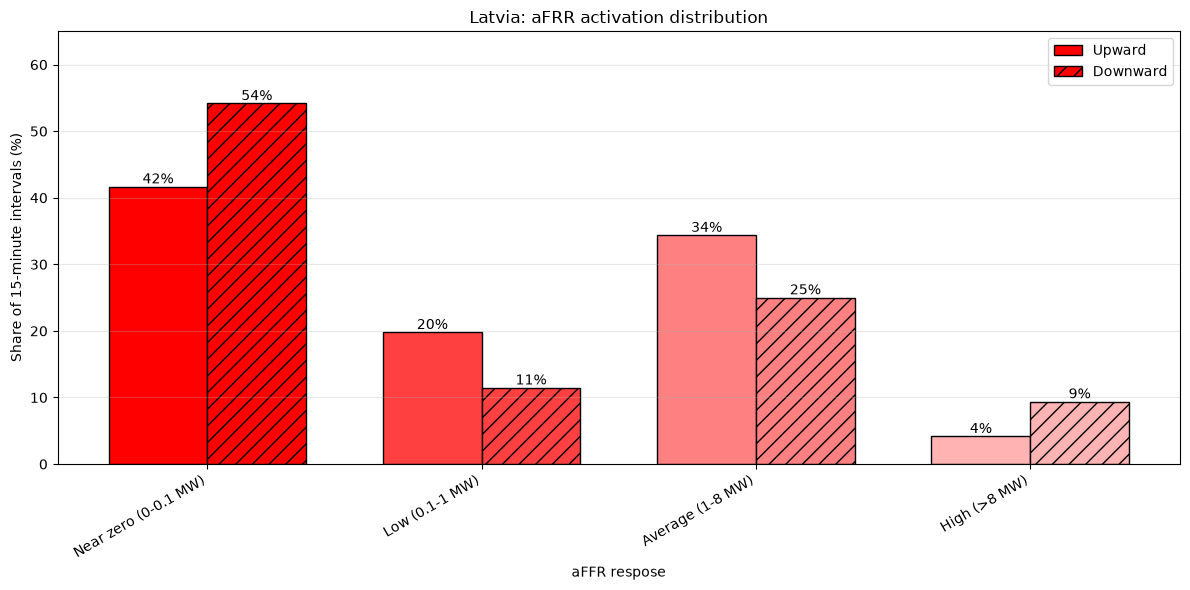

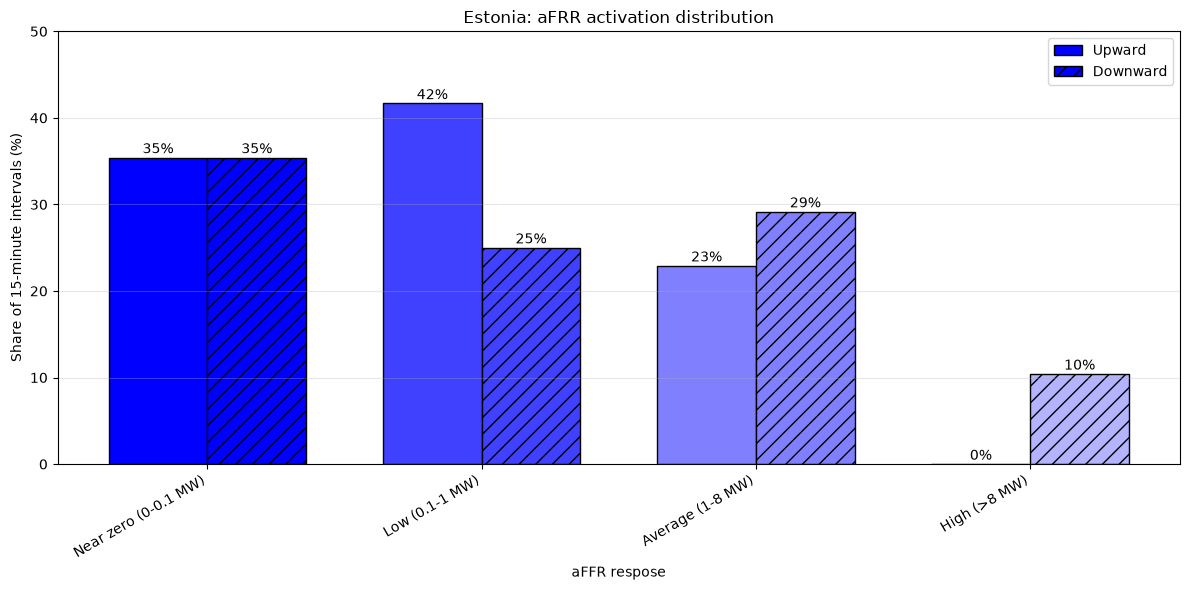

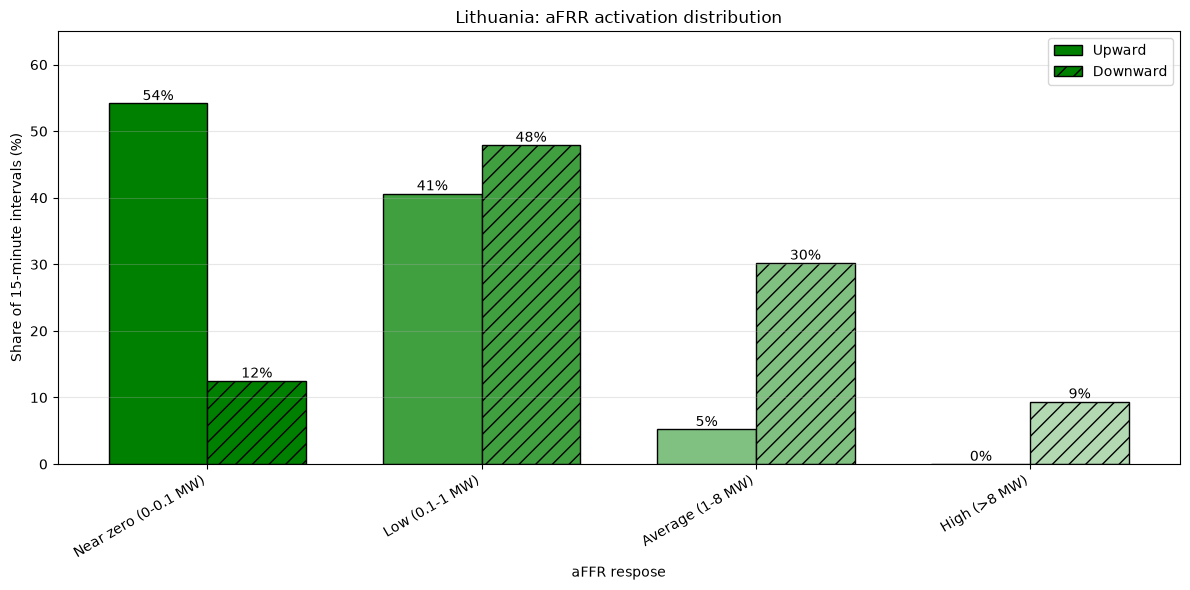

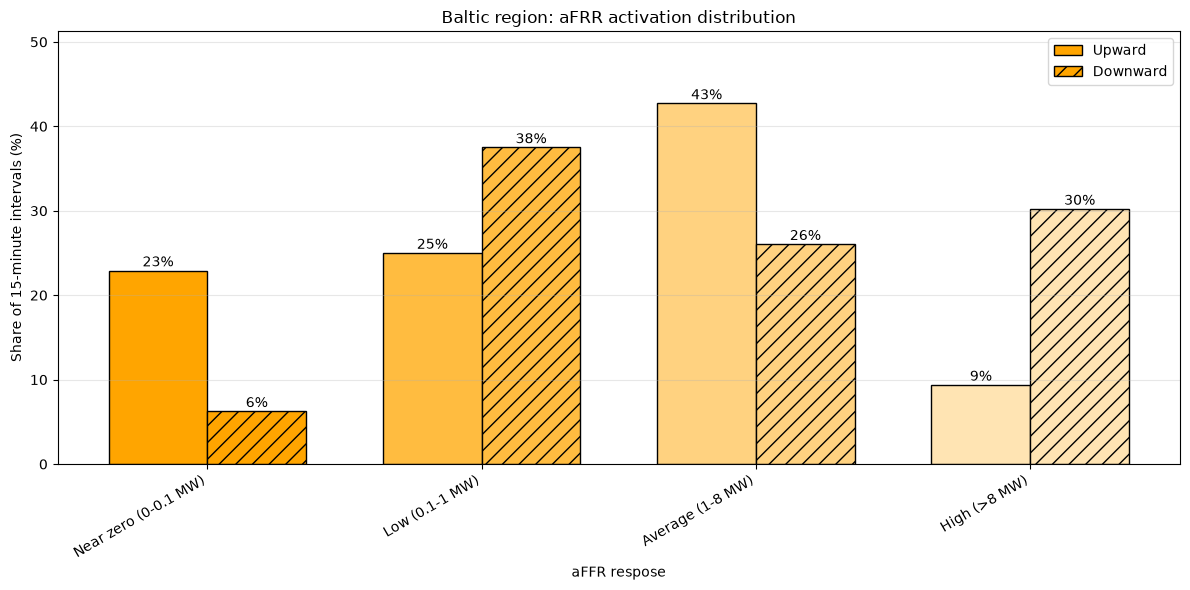

In [54]:
from matplotlib.colors import to_rgb

# Use one base colour per region and progressively lighter shades for smaller tiers.
activation_region_colors = {
    "Latvia": "red",
    "Estonia": "blue",
    "Lithuania": "green",
    "Baltic region": "orange",
}
activation_tiers = list(activation_bands_df.columns)
activation_shade_strength = {
    tier: strength
    for tier, strength in zip(activation_tiers, [0.0, 0.25, 0.5, 0.7])
}


def lighter_color(color, strength):
    # Blend the base colour with white to create a lighter shade.
    base = to_rgb(color)
    return tuple(channel + (1 - channel) * strength for channel in base)


for region, base_color in activation_region_colors.items():
    # Draw paired bars so upward and downward activation can be compared directly.
    region_data = activation_bands_df.loc[region, activation_tiers]
    figure, axis = plt.subplots(figsize=(12, 6))
    positions = range(len(activation_tiers))
    bar_width = 0.36
    colors = [
        lighter_color(base_color, activation_shade_strength[tier])
        for tier in activation_tiers
    ]
    axis.bar(
        [position - bar_width / 2 for position in positions],
        region_data.loc["Upward"],
        width=bar_width,
        color=colors,
        edgecolor="black",
        label="Upward",
    )
    axis.bar(
        [position + bar_width / 2 for position in positions],
        region_data.loc["Downward"],
        width=bar_width,
        color=colors,
        edgecolor="black",
        hatch="//",
        label="Downward",
    )
    axis.set_title(f"{region}: aFRR activation distribution")
    axis.set_xlabel("aFFR respose")
    axis.set_ylabel("Share of 15-minute intervals (%)")
    axis.set_xticks(list(positions), activation_tiers)
    axis.set_ylim(0, max(region_data.max()) * 1.2)
    axis.grid(axis="y", alpha=0.3)
    axis.legend()
    # Put rounded percentage labels above each bar.
    for position, upward_value, downward_value in zip(
        positions, region_data.loc["Upward"], region_data.loc["Downward"]
    ):
        axis.text(position - bar_width / 2, upward_value + 0.5, f"{upward_value:.0f}%", ha="center")
        axis.text(position + bar_width / 2, downward_value + 0.5, f"{downward_value:.0f}%", ha="center")
    figure.autofmt_xdate()
    plt.tight_layout()
    plt.show()

This is a more visual representation of the aFRR activation distribution across the Baltic region and its individual countries. The graph shows the share of 15-minute intervals that fall into different aFRR activation bands, with separate bars for upward and downward activations. The color coding allows for easy comparison between the countries and the overall Baltic region.

Due to the fact that upward and downward aFRR activations can coencide and don't necessarily cancel each other out, the total share of intervals is 200% when summed across upward and downward activations.

As can be seen from the individual country graphs, the majority of aFRR activations fall into the lower activation bands (Near zero and Low), with relatively few intervals reaching the highest activation bands in the given day. This suggests that the aFRR activations are generally moderate in magnitude, with only occasional large activations. The distribution is similar across the individual countries, with some variation in the share of intervals in each activation band. 

However, when summing up aFRR activation across the Baltic region, the distribution is concentrated more evenly across the activation bands, with few periods of near zero activation. Again, signaling that imbalance  correction is being coordinated across the region, rather than being concentrated in one country. This is in agreement with the findings from Metric Nr.3 and Metric Nr.4, which showed that aFRR activations can be more closely aligned with the overall Baltic region's imbalance direction than with the individual countries' imbalance directions.


#### **Metric Nr.6:** Imbalance volume breakdown

**What this section does:** Groups deficit and surplus imbalance values into size bands, showing how often each country and the Baltic region experienced each level.

In [ ]:
imbalance_band_rows = []

# Define the imbalance magnitude bands used in the deficit/surplus breakdown.
imbalance_bands = [
    ("Near zero (0-1 MW)", 0, 1),
    ("Small (1-10 MW)", 1, 10),
    ("Average (10-50 MW)", 10, 50),
    ("Large (>50 MW)", 50, float("inf")),
]

# Keep the sign so deficit and surplus can be reported separately.
imbalance_series = {
    country: imbalance_df[country].astype(float).reindex(activations_df.index)
    for country in countries
}
imbalance_series["Baltic region"] = sum(imbalance_series.values())

for region, values in imbalance_series.items():
    for condition_name, direction_mask in [
        ("Deficit", values < 0),
        ("Surplus", values > 0),
    ]:
        absolute_values = values.abs()
        band_percentages = {"Region": region, "Condition": condition_name}
        for label, lower_bound, upper_bound in imbalance_bands:
            # Count only intervals with the selected sign and magnitude band.
            if upper_bound == float("inf"):
                in_band = direction_mask & (absolute_values > lower_bound)
            elif lower_bound == 0:
                in_band = (
                    direction_mask
                    & (absolute_values >= lower_bound)
                    & (absolute_values <= upper_bound)
                )
            else:
                in_band = (
                    direction_mask
                    & (absolute_values > lower_bound)
                    & (absolute_values <= upper_bound)
                )
            band_percentages[label] = in_band.mean() * 100
        imbalance_band_rows.append(band_percentages)

imbalance_bands_df = pd.DataFrame(imbalance_band_rows).set_index(["Region", "Condition"])
imbalance_percentage_columns = imbalance_bands_df.columns
imbalance_bands_display = imbalance_bands_df.copy()
# Add percent signs for the reader while retaining the numeric dataframe for plotting.
imbalance_bands_display[imbalance_percentage_columns] = imbalance_bands_display[
    imbalance_percentage_columns
].apply(lambda column: column.map(lambda value: f"{value:.0f}%"))
print("Imbalance-band values are percentages of the day's 15-minute intervals.")
print("Deficit means negative imbalance; surplus means positive imbalance.")
display(imbalance_bands_display)

Imbalance-band values are percentages of the day's 15-minute intervals.
Deficit means negative imbalance; surplus means positive imbalance.


Near zero (0-1 MW) Small (1-10 MW) Average (10-50 MW)  \
Region        Condition                                                         
Latvia        Deficit                   6%             29%                17%   
              Surplus                   9%             36%                 2%   
Estonia       Deficit                   4%              4%                 2%   
              Surplus                   4%             19%                56%   
Lithuania     Deficit                   4%             15%                19%   
              Surplus                   2%             25%                28%   
Baltic region Deficit                   2%              5%                12%   
              Surplus                   1%             11%                53%   

                        Large (>50 MW)  
Region        Condition                 
Latvia        Deficit               0%  
              Surplus               0%  
Estonia       Deficit               0%  
              Surplus              10%  
Lithuania     Deficit               1%  
              Surplus               6%  
Baltic region Deficit               2%  
              Surplus              12%

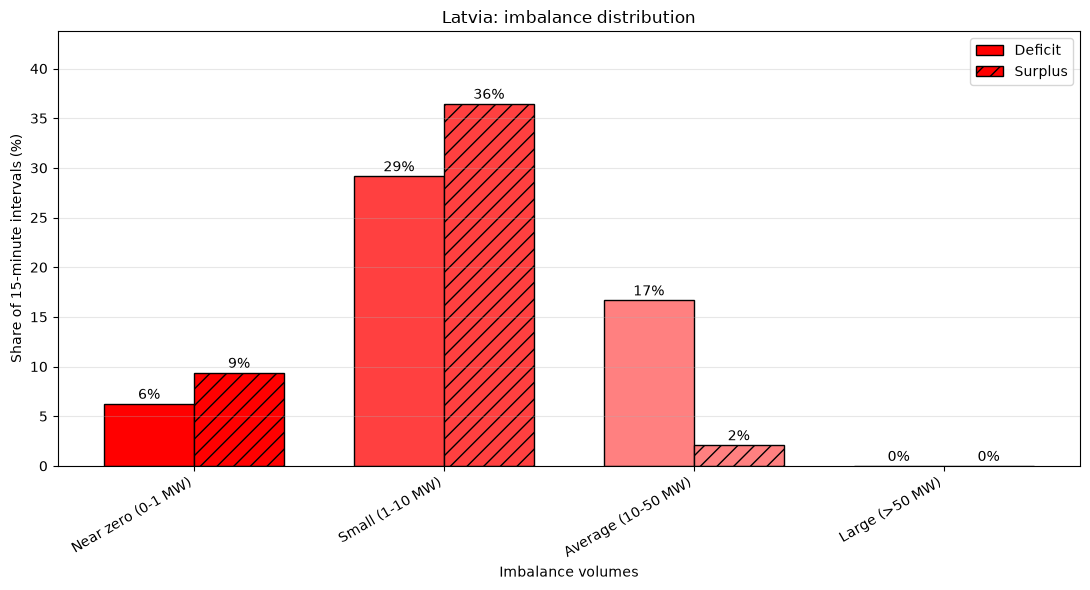

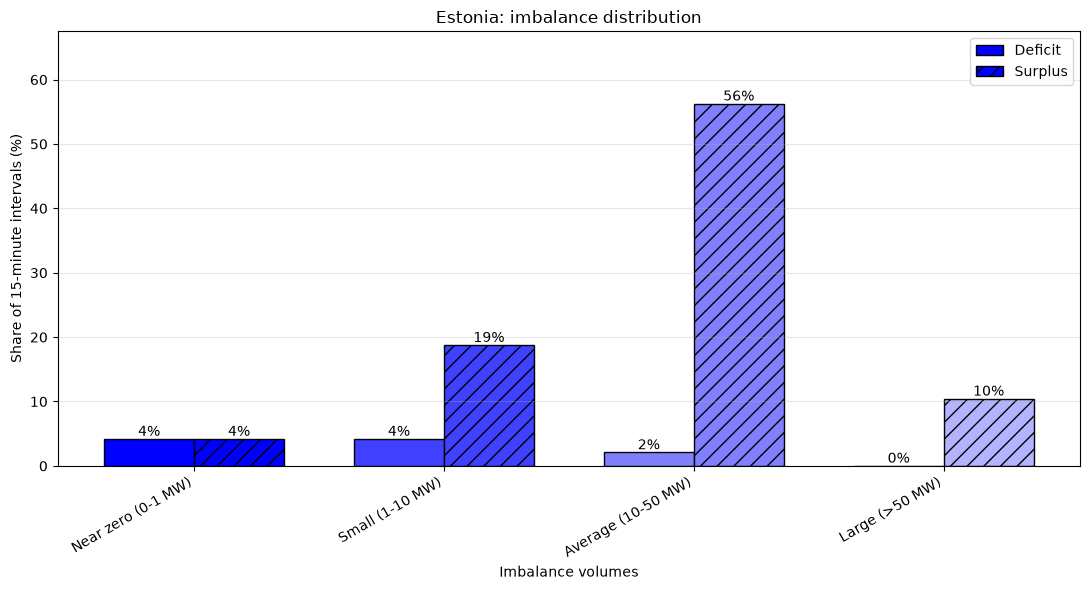

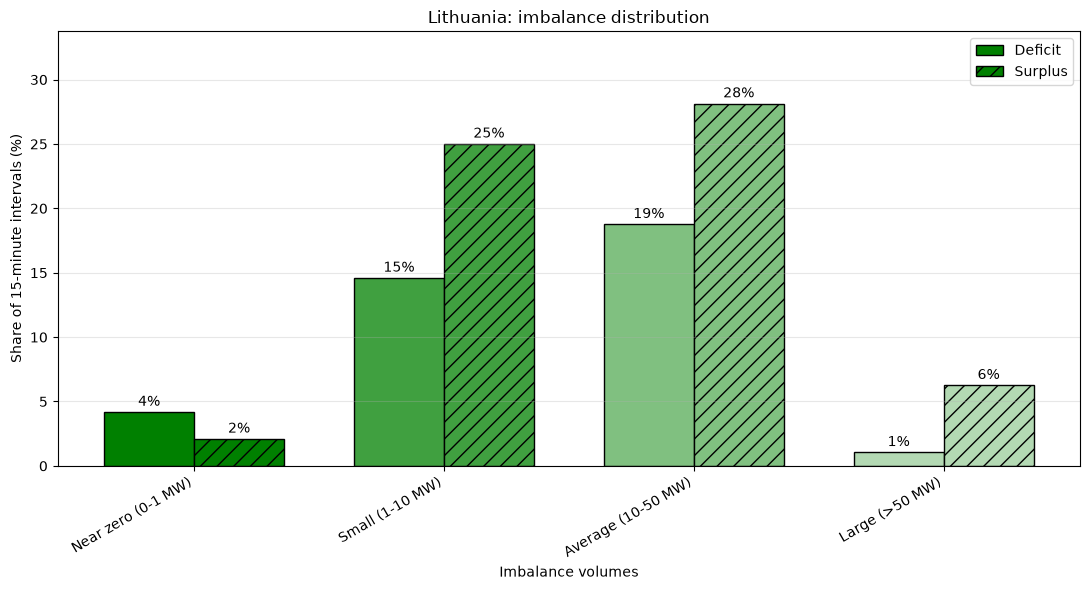

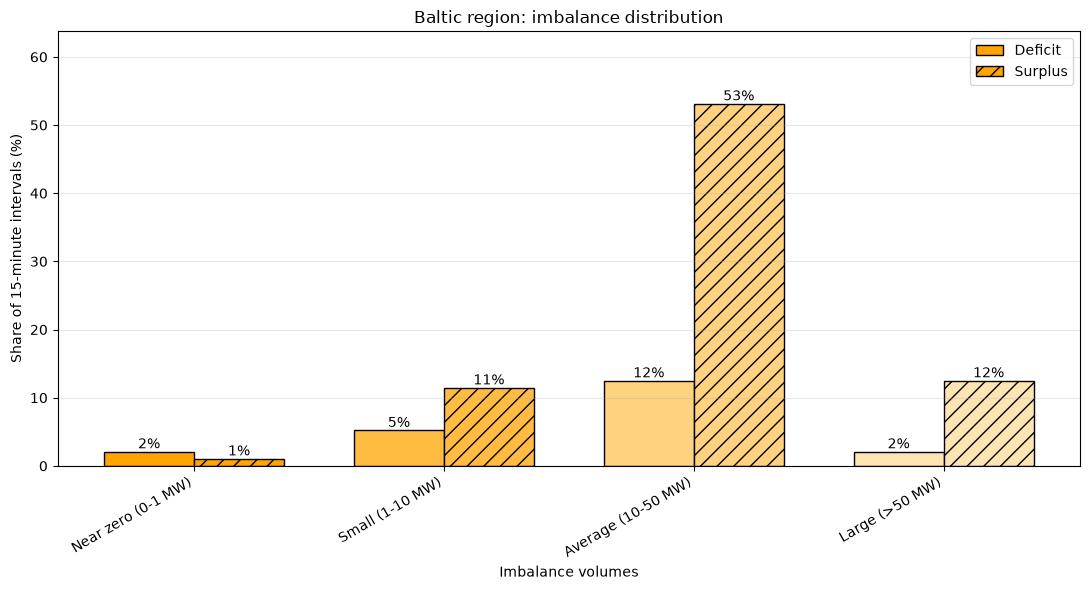

In [ ]:
# Use the same country colours as the activation charts.
imbalance_region_colors = {
    "Latvia": "red",
    "Estonia": "blue",
    "Lithuania": "green",
    "Baltic region": "orange",
}
imbalance_tiers = list(imbalance_bands_df.columns)
imbalance_shade_strength = {
    tier: strength
    for tier, strength in zip(imbalance_tiers, [0.0, 0.25, 0.5, 0.7])
}

for region, base_color in imbalance_region_colors.items():
    # Draw paired deficit and surplus bars for every imbalance tier.
    region_data = imbalance_bands_df.loc[region, imbalance_tiers]
    figure, axis = plt.subplots(figsize=(11, 6))
    positions = range(len(imbalance_tiers))
    bar_width = 0.36
    colors = [
        lighter_color(base_color, imbalance_shade_strength[tier])
        for tier in imbalance_tiers
    ]
    axis.bar(
        [position - bar_width / 2 for position in positions],
        region_data.loc["Deficit"],
        width=bar_width,
        color=colors,
        edgecolor="black",
        label="Deficit",
    )
    axis.bar(
        [position + bar_width / 2 for position in positions],
        region_data.loc["Surplus"],
        width=bar_width,
        color=colors,
        edgecolor="black",
        hatch="//",
        label="Surplus",
    )
    axis.set_title(f"{region}: imbalance distribution")
    axis.set_xlabel("Imbalance volumes")
    axis.set_ylabel("Share of 15-minute intervals (%)")
    axis.set_xticks(list(positions), imbalance_tiers)
    axis.set_ylim(0, max(region_data.max()) * 1.2)
    axis.grid(axis="y", alpha=0.3)
    axis.legend()
    # Label each bar with its rounded percentage.
    for position, deficit_value, surplus_value in zip(
        positions, region_data.loc["Deficit"], region_data.loc["Surplus"]
    ):
        axis.text(position - bar_width / 2, deficit_value + 0.5, f"{deficit_value:.0f}%", ha="center")
        axis.text(position + bar_width / 2, surplus_value + 0.5, f"{surplus_value:.0f}%", ha="center")
    figure.autofmt_xdate()
    plt.tight_layout()
    plt.show()

This is a more visual representation of the imbalance distribution across the Baltic region and its individual countries. The graph shows the share of 15-minute intervals that fall into different imbalance bands, with separate bars for surplus and deficit imbalances. The total sum of the shares for each region is 100%, thus allowing for easy comparison of the most common imbalance magnitudes across the countries and the overall Baltic region.

For the majority of intervals on this day, there was a surplus of power in the Baltic region in the range of 10-50 MW, which was mainly caused by a continuous surplus in Estonia and Lithuania. Generally, Latvia had the largest share of intervals with near-zero imbalance, which is consistent with the findings from the previous metrics. Intuitively, this aligns with the very different imbalance patterns observed in the previous imbalance volume plot.

### Assessment of regulation activities - 22.09.2025
Background & metric rationale

The Baltic states run as one synchronous LFC block, but aFRR activation and imbalance are still measured and settled per country. This assessment asks, at both the country and regional level: how much of each country's imbalance did aFRR actually correct, was it correcting the right direction, and how much of the country-level pattern is just a function of imbalance size rather than activation efficiency?

Three groups of metrics were considered in order to assess different questions about the relationship between aFRR activation and imbalance that a plain time-series read would blur:

-  Coverage needed an energy-based sum-of-totals ratio, not a per-interval average — per-interval ratios blow up whenever the imbalance denominator is near zero (confirmed directly in the notebook: mean vs. median coverage differ 5–10x).

-  Direction needed two complementary statistics: Pearson correlation (dominated by the largest intervals, since it's built from squared deviations) and an |imbalance|-weighted direction-match rate (a plain linear average, so it can't be dominated by a few extremes). Together they show not just whether activation opposes imbalance, but whether that holds broadly or is carried by a handful of large episodes.

-  Volatility (imbalance-size distribution) was added to explain, not just describe, the coverage and direction results. Capacity-limited local aFRR products structurally struggle against larger, more volatile imbalances regardless of how efficiently it's dispatched.

1) Coverage of imbalance by aFRR

Using the aggregate (sum of activated MWh / sum of gross |imbalance| MWh) figure, aFRR covered 56% of Latvia's daily imbalance but only 16% of Estonia's and 16% of Lithuania's - despite Estonia and Lithuania each activating a comparable volume of aFRR (71 MWh and 64 MWh against Latvia's 84 MWh). The gap is explained by imbalance size, not activation shortfall: Estonia's and Lithuania's total imbalance (442 MWh and 404 MWh) each dwarfed Latvia's (149 MWh). Regionally, aFRR covered 22% of the Baltic region's gross imbalance.

2) Direction of activation

Correlation between signed aFRR activation and imbalance is positive but moderate, following the same ranking as coverage: Latvia strongest (r ≈ 0.50), Estonia and Lithuania weaker (r ≈ 0.34–0.35), the pooled region highest of all (r ≈ 0.53). The weighted direction-match rate tells a related but distinct story: Latvia's aFRR opposed its own imbalance correctly ~89% of the time, Estonia's and Lithuania's only ~63%, and the region ~68% — notably lower than Latvia alone, despite the region having the highest correlation. That combination means the region's correlation is carried by a handful of large, well-matched episodes rather than holding uniformly. This is consistent with a shared LFC block dispatching aFRR against the regional imbalance: a country can show a local deficit while its own aFRR activates downward if that's what the block-wide balance requires.

3) Volatility

Latvia's imbalance was small and largely tame: ~65% of intervals were near-zero or a small deficit/surplus, with essentially no intervals above 50 MW. Estonia spent 66% of the day in a sizable surplus (>10 MW), with 10% of intervals exceeding 50 MW. Lithuania swung between states — 34% of intervals in a sizable surplus and a further 20% in a sizable deficit — the most volatile of the three. This lines up directly with the coverage and correlation results: the two countries with the largest, most volatile imbalances (Estonia, Lithuania) are also the two with the lowest coverage and weakest direction alignment.

4) Overall conclusion

aFRR activation on this day tracked the general sign and shape of the region's imbalance but came nowhere close to fully covering it in energy terms — expected, since aFRR is only one layer of a balancing stack that also includes mFRR, cross-border exchange, and manual balancing. The sharp country-level asymmetry (Latvia far outperforming Estonia and Lithuania on both coverage and direction match) is best explained by two compounding factors: Estonia and Lithuania simply carried larger, more volatile imbalances that day, and the shared Baltic LFC block means aFRR is dispatched against the regional signal, which doesn't always align with any one country's local position. Confirming the LFC-block explanation specifically (versus, say, under-contracted local aFRR capacity) would need mFRR activation and net interconnector flow data for the same day, which is outside this export.